# Iris Dataset

---

## Project Aim

The goal of this project is to use **unsupervised machine learning**
to discover natural groupings within the Iris flower dataset —
without being told the groups in advance.

---

## Dataset Overview

| Property | Details |
|---|---|
| Dataset Name | Iris Flower Dataset |
| Collected by | Edgar Anderson (1936) |
| Total flowers | 150 |
| Species | 3 (Setosa, Versicolor, Virginica) |
| Flowers per species | 50 each |
| Total features | 4 measurements + 1 species label |

---

## Data Dictionary

| Feature | Unit | Description |
|---|---|---|
| `sepal length` | cm | Length of the outer green leaf of the flower |
| `sepal width` | cm | Width of the outer green leaf of the flower |
| `petal length` | cm | Length of the inner colourful part of the flower |
| `petal width` | cm | Width of the inner colourful part of the flower |
| `species` | category | 0 = Setosa, 1 = Versicolor, 2 = Virginica |

---

## The 3 Species

| Label | Species | Characteristics |
|---|---|---|
| 0 | Setosa | Smallest flowers, very distinct and easy to separate |
| 1 | Versicolor | Medium-sized, slight overlap with Virginica |
| 2 | Virginica | Largest flowers, slight overlap with Versicolor |

In [6]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')


In [7]:
# Load dataset - Using Iris for clustering
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(df.head())

Dataset loaded!
Shape: (150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [8]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [26]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [9]:
# Feature Engineering: Create new features
df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']
df['sepal_ratio'] = df['sepal length (cm)'] / df['sepal width (cm)']
df['petal_area'] = df['petal length (cm)'] * df['petal width (cm)']

print("New features created:")
print(df[['petal_ratio', 'sepal_ratio', 'petal_area']].head())

New features created:
   petal_ratio  sepal_ratio  petal_area
0          7.0     1.457143        0.28
1          7.0     1.633333        0.28
2          6.5     1.468750        0.26
3          7.5     1.483871        0.30
4          7.0     1.388889        0.28


In [10]:
# Prepare features for clustering
X = df.drop('species', axis=1)

In [11]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
print(f"Features scaled: {X_scaled.shape}")

Features scaled: (150, 7)


In [13]:
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
print("K-Means Clustering:")
print(df['kmeans_cluster'].value_counts().sort_index())
print(f"Silhouette Score: {silhouette_score(X_scaled, df['kmeans_cluster']):.3f}")

K-Means Clustering:
kmeans_cluster
0    50
1    39
2    61
Name: count, dtype: int64
Silhouette Score: 0.428


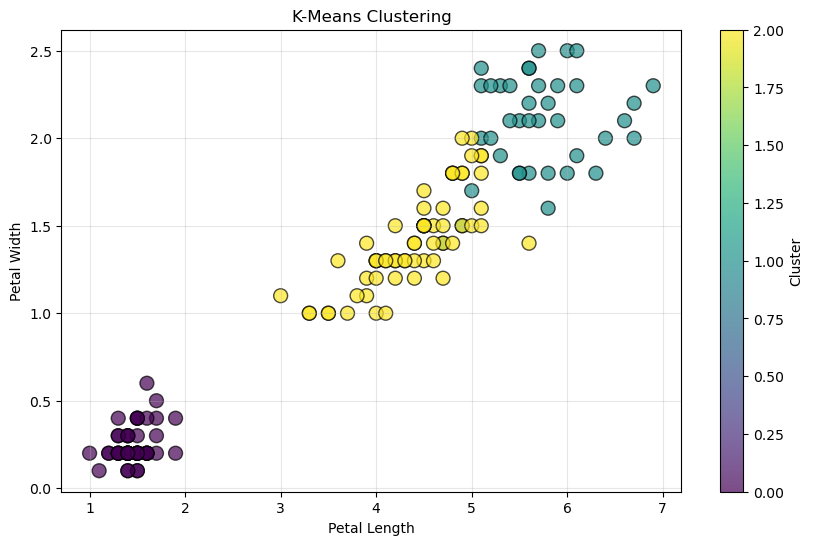

In [15]:
# Visualize K-Means clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['petal length (cm)'], df['petal width (cm)'], 
                     c=df['kmeans_cluster'], cmap='viridis', 
                     s=100, edgecolor='black', alpha=0.7)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clustering')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Clustering:")
print(df['dbscan_cluster'].value_counts().sort_index())
print(f"Number of clusters: {len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'] else 0)}")
print(f"Noise points: {sum(df['dbscan_cluster'] == -1)}")

DBSCAN Clustering:
dbscan_cluster
-1    97
 0    22
 1    26
 2     5
Name: count, dtype: int64
Number of clusters: 4
Noise points: 97


In [17]:
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

print("Hierarchical Clustering:")
print(df['hierarchical_cluster'].value_counts().sort_index())

Hierarchical Clustering:
hierarchical_cluster
0    49
1    73
2    28
Name: count, dtype: int64


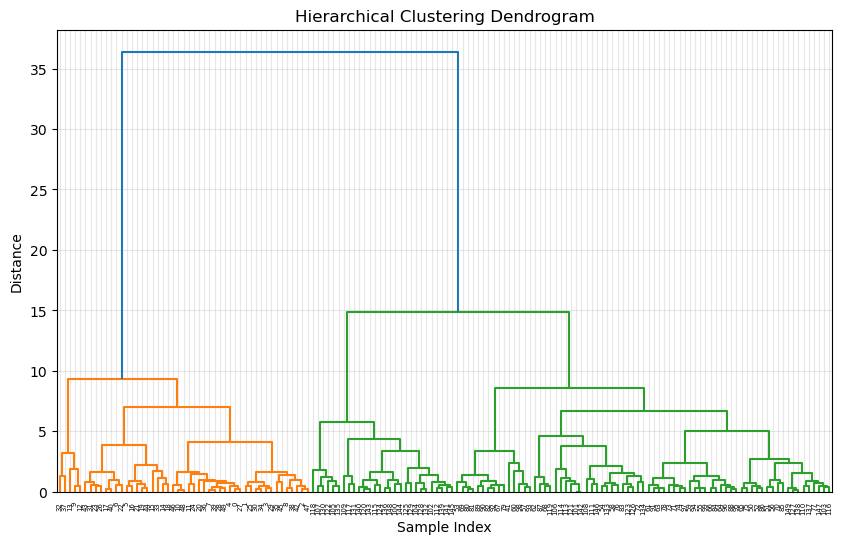

In [18]:
# Visualize Dendrogram
plt.figure(figsize=(10, 6))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.grid(True, alpha=0.3)
plt.show()

## Explanation of teh Dendogram above

A **dendrogram** is a tree diagram that shows how the hierarchical
clustering algorithm grouped the 150 flowers step by step.

---

### The Axes

| Axis | What It Means |
|---|---|
| **X-axis (bottom)** | Each number represents one flower from the dataset |
| **Y-axis (left)** | Distance — how different two groups are when they merge. **Higher = more different** |

---

### How to Read It — Start from the Bottom

- At the **very bottom**, individual flowers that are almost identical
  merge first at very low heights
- As you move **upward**, bigger and bigger groups merge together
- The **height at which two branches connect** tells you how different
  those two groups were — a tall vertical line means the two groups
  are very different from each other

---

### What the Colours Mean

| Colour | What It Represents |
|---|---|
| 🟠 **Orange (left)** | Group 1 — these flowers are all very similar to each other and merge early at low distances. These are the **Setosa** flowers |
| 🟢 **Green (middle + right)** | Groups 2 and 3 — these flowers are more varied and merge at higher distances. These are **Versicolor** and **Virginica** |
| 🔵 **Blue line at the top** | The final merge — at distance ~36, all groups combine into one |

---

### The Most Important Thing to Notice

> Look at the **big gap** between the green merges (around height 15)
> and the final blue merge (around height 36).
>
> That huge gap tells us the **orange group (Setosa) is dramatically
> different** from the other two groups — they are very easy to separate.
>
> The smaller gap between the two green groups tells us **Versicolor
> and Virginica are more similar** to each other and harder to separate.

---

### How This Helps Us Choose the Number of Clusters

Draw an imaginary horizontal line across the chart.
Count how many vertical lines that imaginary line crosses.
That number = your recommended number of clusters.

- Draw the line at **height 20** → crosses **3 vertical lines** → suggests **k = 3**
- This confirms that **3 clusters** is the right choice for this dataset

In [19]:
# PCA - Dimensionality Reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA Results:")
print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.3f}")

PCA Results:
Explained variance: [0.73919628 0.1547796 ]
Total variance explained: 0.894


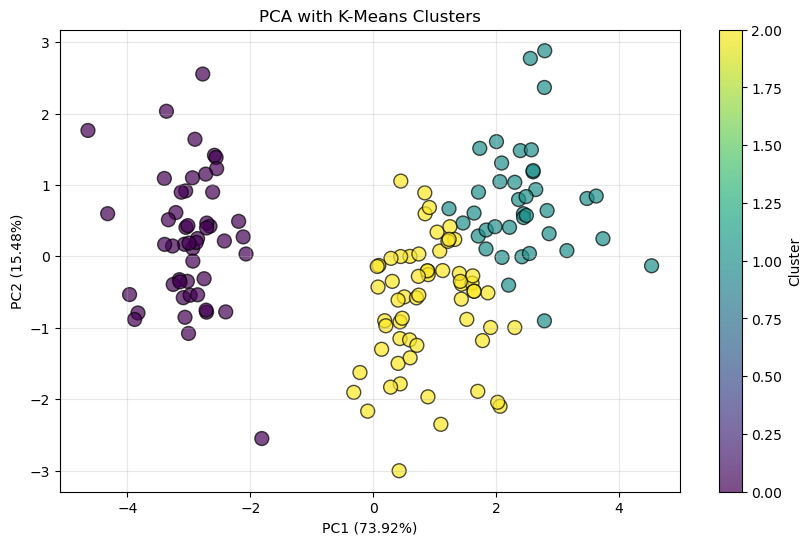

In [20]:
# Visualize PCA with clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df['kmeans_cluster'], cmap='viridis',
                     s=100, edgecolor='black', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA with K-Means Clusters')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## How to Read This Chart — PCA with K-Means Clusters

This chart is showing us the **clustering results in 2D** using a technique
called **PCA (Principal Component Analysis)**.

---

### Why Do We Need PCA Here?

Our dataset has **7 features** (columns).
It is impossible to plot 7 dimensions on a screen.

PCA **compresses** all 7 features down to just **2 values** per flower
so we can actually see the clusters visually — while keeping
as much of the original information as possible.

> Think of it like taking a **3D sculpture and shining a light on it**
> to cast a 2D shadow on the wall. You lose some detail but you can
> still clearly see the overall shape.

---

### The Axes

| Axis | What It Means |
|---|---|
| **X-axis — PC1 (73.92%)** | The first principal component. It captures **73.92% of all the variation** in the data. This is the most important direction. |
| **Y-axis — PC2 (15.48%)** | The second principal component. It captures **15.48% of the variation**. |
| **Together** | PC1 + PC2 capture **~89% of all information** in just 2 dimensions |

---

### What Each Dot Means

- Every **dot** = one flower from the dataset (150 dots total)
- The **position** of the dot is determined by its PC1 and PC2 values
- The **colour** of the dot shows which K-Means cluster it was assigned to

---

### What the Colours Mean

| Colour | Cluster | What It Represents |
|---|---|---|
| 🟣 **Purple (left side)** | Cluster 0 | Small flowers — these are the **Setosa** species. Very tightly grouped and clearly separated from the rest |
| 🟡 **Yellow (middle)** | Cluster 1 | Medium flowers — mostly **Versicolor** species |
| 🔵 **Teal/Green (right)** | Cluster 2 | Large flowers — mostly **Virginica** species |

---

### What This Chart Is Telling Us

**1. The purple group is very well separated**
- All purple dots are on the far left, far away from the others
- This means Setosa flowers are **very different** from the other two species
- The algorithm found this group easily and confidently

**2. The yellow and teal groups overlap slightly**
- In the middle-right area you can see yellow and teal dots mixing
- This means Versicolor and Virginica are **naturally similar** to each other
- This is why the silhouette score is not perfect — some flowers
  sit on the boundary between these two groups

**3. The clustering result is meaningful**
- Even though the algorithm was **never told** which species is which,
  it discovered groups that almost perfectly match the real biological species
- This is the power of unsupervised learning

---

### Key Takeaway

> If the dots of different colours are **far apart** from each other
> on this chart, it means the clusters are **well separated** — good clustering.
>
> If dots of different colours are **mixed together**,
> it means those clusters **overlap** — harder to separate.

In [21]:
# Cluster Profiling - Understand each cluster
cluster_profile = df.groupby('kmeans_cluster').mean()

print("Cluster Profiles:")
print(cluster_profile)

Cluster Profiles:
                sepal length (cm)  sepal width (cm)  petal length (cm)  \
kmeans_cluster                                                           
0                        5.006000          3.428000           1.462000   
1                        6.846154          3.082051           5.702564   
2                        5.888525          2.737705           4.396721   

                petal width (cm)   species  petal_ratio  sepal_ratio  \
kmeans_cluster                                                         
0                       0.246000  0.000000     6.908000     1.470188   
1                       2.079487  1.923077     2.786067     2.236973   
2                       1.418033  1.229508     3.156039     2.168866   

                petal_area  dbscan_cluster  hierarchical_cluster  
kmeans_cluster                                                    
0                 0.365600       -0.560000              0.020000  
1                11.892821       -0.897436       

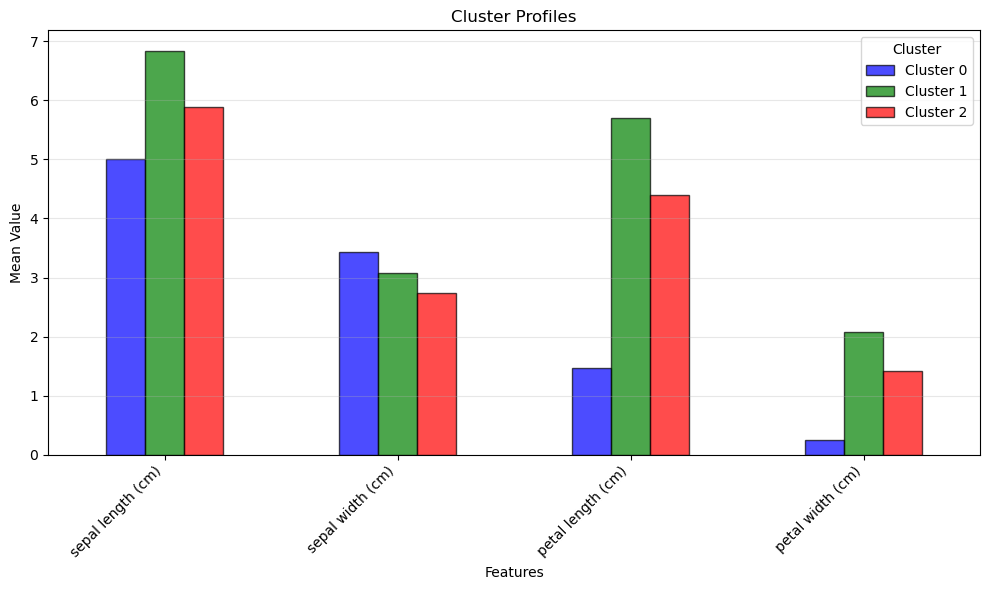

In [22]:
# Visualize cluster profiles
cluster_profile_subset = cluster_profile[['sepal length (cm)', 'sepal width (cm)', 
                                          'petal length (cm)', 'petal width (cm)']]

cluster_profile_subset.T.plot(kind='bar', figsize=(10, 6), 
                              color=['blue', 'green', 'red'], 
                              edgecolor='black', alpha=0.7)
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.title('Cluster Profiles')
plt.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 📊 How to Read This Chart — Cluster Profiles

This chart shows the **average (mean) value of each feature
for each cluster** — so we can understand what makes
each cluster unique and different from the others.

---

### The Axes

| Axis | What It Means |
|---|---|
| **X-axis (bottom)** | The 4 original flower measurements (features) |
| **Y-axis (left)** | Mean Value — the average measurement for that cluster |

---

### What the Colours Mean

| Colour | Cluster | Species It Matches |
|---|---|---|
| 🔵 **Blue** | Cluster 0 | **Setosa** — the smallest flowers |
| 🟢 **Green** | Cluster 1 | **Virginica** — the largest flowers |
| 🔴 **Red** | Cluster 2 | **Versicolor** — the medium flowers |

---

### Reading the Chart Group by Group

**Sepal Length (first group of bars)**
- Green is tallest (~6.8) → Cluster 1 has the longest sepals
- Red is middle (~5.9) → Cluster 2 is in between
- Blue is shortest (~5.0) → Cluster 0 has the shortest sepals

**Sepal Width (second group of bars)**
- Blue is tallest (~3.4) → Cluster 0 actually has the widest sepals
- Green and Red are close together (~3.1 and ~2.8)

**Petal Length (third group of bars)**
- Green is tallest (~5.7) → Cluster 1 has the longest petals by far
- Red is middle (~4.4)
- Blue is very short (~1.5) → Cluster 0 has tiny petals

**Petal Width (fourth group of bars)**
- Green is tallest (~2.1) → Cluster 1 has the widest petals
- Red is middle (~1.4)
- Blue is almost zero (~0.25) → Cluster 0 has very narrow petals

---

### The Pattern to Notice

> Look at the **blue bars** across all 4 features —
> they are consistently the **shortest** in petal length and petal width.
> This tells us Cluster 0 (Setosa) is a **small flower** in almost every measurement.
>
> Look at the **green bars** — they are consistently the **tallest**.
> This tells us Cluster 1 (Virginica) is the **largest flower** across the board.
>
> The **red bars** always sit **in between** the other two.

---

### What This Chart Is Telling Us

This chart answers the question:
**"Now that we have clusters, what actually makes them different?"**

- Cluster 0 = small compact flowers with tiny petals → **Setosa**
- Cluster 1 = large flowers with long wide petals → **Virginica**
- Cluster 2 = medium flowers that sit between the two → **Versicolor**

> The algorithm was **never told** any of this.
> It discovered these differences entirely on its own
> just by looking at the numbers — and it was right.
> That is the power of clustering.

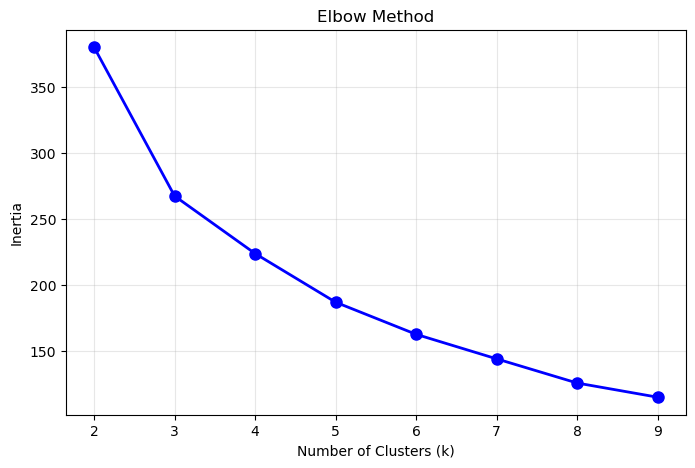

Look for the 'elbow' point to find optimal k


In [23]:
# Elbow Method - Find optimal number of clusters
inertias = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()

print("Look for the 'elbow' point to find optimal k")

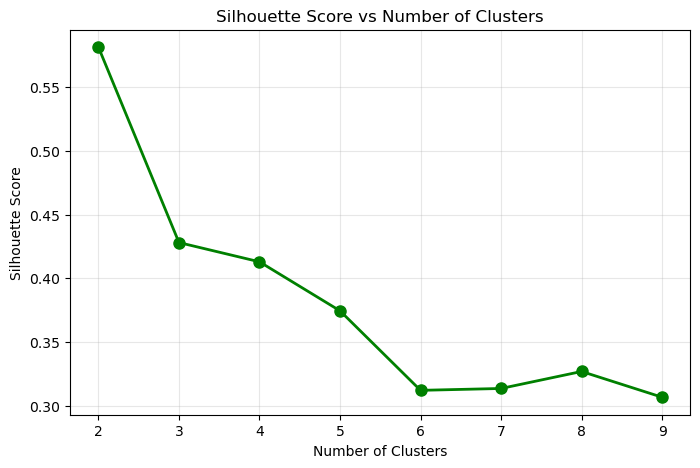

In [24]:
# Silhouette Score - Evaluate clustering quality
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
print(f"Best k: {silhouette_scores.index(max(silhouette_scores)) + 2}")
print(f"Best score: {max(silhouette_scores):.3f}")

Best k: 2
Best score: 0.582


## Silhouette Score vs Number of Clusters

This chart helps us answer one important question:
**"How many clusters should we use?"**

---

### What is the Silhouette Score?

The **Silhouette Score** measures how good our clustering is.
It checks two things at the same time:

- How **tight** each cluster is — are points within a cluster close to each other?
- How **separated** clusters are — are clusters far away from each other?

| Score Range | What It Means |
|---|---|
| Close to **1.0** | Clusters are tight and well separated — excellent |
| Around **0.5** | Reasonable clustering — decent separation |
| Around **0.0** | Clusters are overlapping — poor |
| **Negative** | Points may be in the wrong cluster — very poor |

---

### The Axes

| Axis | What It Means |
|---|---|
| **X-axis (bottom)** | Number of clusters (k) — we tested k = 2 all the way to k = 9 |
| **Y-axis (left)** | Silhouette Score — higher is always better |

---

### Reading the Line Point by Point

| k | Score | What It Means |
|---|---|---|
| **k = 2** | ~0.582 | Highest score — best cluster separation mathematically |
| **k = 3** | ~0.428 | Score drops — clusters start overlapping more |
| **k = 4** | ~0.414 | Continues to drop |
| **k = 5 to 9** | keeps falling | Adding more clusters keeps making things worse |

---

### What the Output Is Saying
```
Best k: 2
Best score: 0.582
```

Mathematically, **k = 2** gives the cleanest separation.

---

### But Wait — Should We Use k = 2 or k = 3?

> **Two methods can give different answers — and both can be right.**

| Method | Says | Why |
|---|---|---|
| **Silhouette Score** | k = 2 is best | Mathematically the two groups are most distinct |
| **Elbow Method** | k = 3 is best | Inertia drops most sharply at k = 3 |
| **Domain Knowledge** | k = 3 makes sense | We know biologically there are 3 iris species |

